### Setup 
Exercise 1: Import libraries and load a clean test image

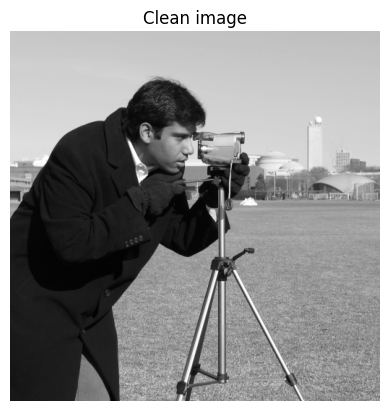

image shape: (512, 512), min: 0.0, max: 1.0, mean intensity: 0.51


In [31]:
import numpy as np 
import matplotlib.pyplot as plt 
from skimage import data, util, exposure 
from scipy.ndimage import uniform_filter, median_filter 
img = data.camera().astype(np.float32) / 255.0 # to make it range between 0,1
 
plt.imshow(img, cmap="gray") 
plt.title("Clean image") 
plt.axis("off") 
plt.show() 

# Task 
# 1. Print the image shape, min, max, and mean intensity. 
print(f"image shape: {img.shape}, min: {img.min()}, max: {img.max()}, mean intensity: {img.mean():.2f}")

### 1. Degradation model 
Exercise 1.1: Simulate additive noise and verify the model (code)

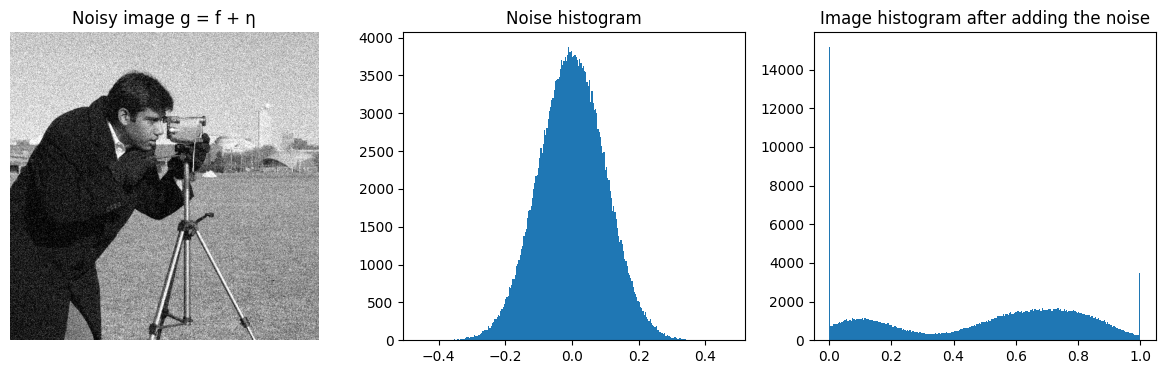

Difference between the noise and residual: 0.00
MSE of the noise and residual: 2.09e-16


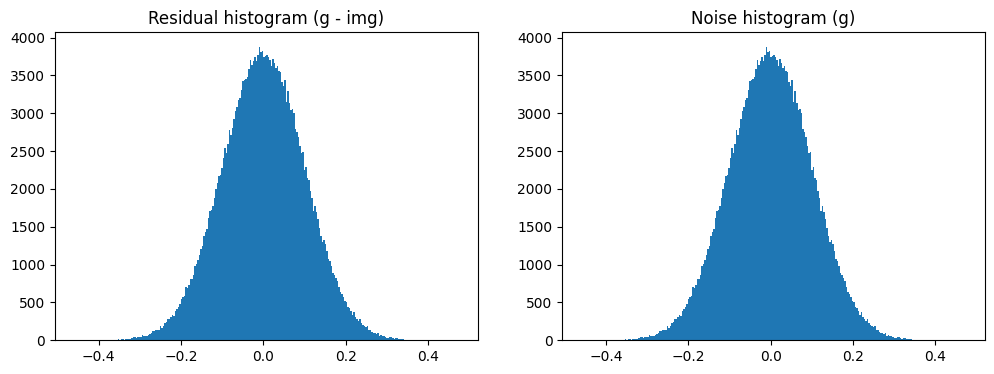

'because it mimics real-world cameras when they produce images they are mostly \nin the form of g = image + noise'

In [33]:
rng = np.random.default_rng(0) # unify the seed
 
sigma = 0.1 # u can change it, i made it 0.1 and the mse went to 0.009

noise = rng.normal(0, sigma, img.shape).astype(np.float32) 
g = np.clip(img + noise, 0, 1) 


plt.figure(figsize=(15,4)) 
plt.subplot(1,3,1) 
plt.imshow(g, cmap="gray") 
plt.title("Noisy image g = f + η") 
plt.axis("off") 
 
plt.subplot(1,3,2) 
plt.hist(noise.flatten(), bins=256) # this is the array of the noise (just the noise)
plt.title("Noise histogram")

plt.subplot(1,3,3)
plt.title("Image histogram after adding the noise") 
plt.hist(g.flatten(), bins=256) # this is the image with the noise added
plt.show()

# Tasks 
# 1. Compute the residual g - img and verify it matches the generated noise distribution. 
residual = (noise + img) - img # do not use g - img since g is already clipped
difference = residual - noise
print(f"Difference between the noise and residual: {np.max(np.abs(difference)):.2f}")
print(f"MSE of the noise and residual: {np.mean(difference**2):.2e}") # super small number close to zero

# plot the residual
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.hist(residual.flatten(), bins=256)
plt.title("Residual histogram (g - img)")

plt.subplot(1,2,2)
plt.hist(noise.flatten(), bins=256)
plt.title("Noise histogram (g)")
plt.show()

# 2. Explain why additive noise is a reasonable model for many sensors. 
'''because it mimics real-world cameras when they produce images they are mostly 
in the form of g = image + noise'''

### 2. Gaussian noise 
Exercise 2.1: Quantify the effect of Gaussian noise (code) 

MSE (clean vs noisy): 0.009061243385076523


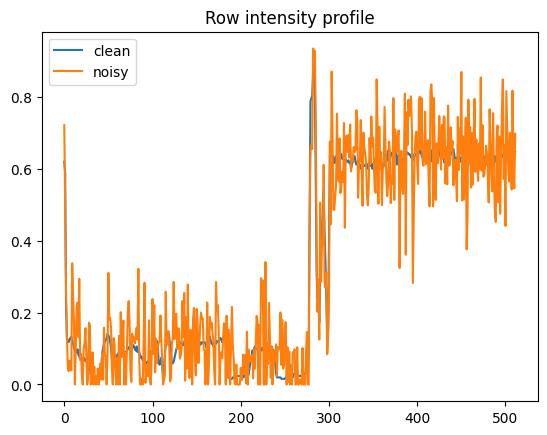

In [34]:
def mse(a, b): 
    a = a.astype(np.float32) 
    b = b.astype(np.float32) 
    return float(np.mean((a - b) ** 2)) 
 
mse_noisy = mse(img, g) 
print("MSE (clean vs noisy):", mse_noisy) 

# Tasks 
# 1. Increase sigma and report how MSE changes. 
'''noise becomes larger and its effect is stronger on the image'''

# 2. Plot the noisy image row profile and compare with the clean profile. 
# Starter: 
r = img.shape[0] // 2 # take the middle row
plt.plot(img[r, :], label="clean") 
plt.plot(g[r, :], label="noisy") 
plt.title("Row intensity profile") 
plt.legend() 
plt.show() 

### 3. Impulse (salt and pepper) noise 
Exercise 3.1: Add salt and pepper noise and measure corruption level 
(code) 

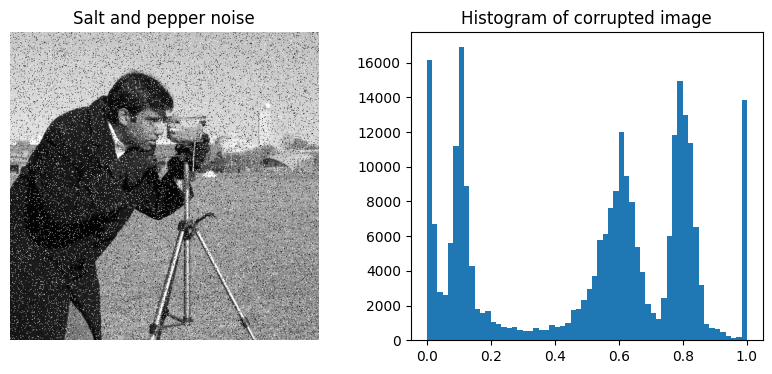

pixels at zero: 5.008%
pixels at one: 5.084%
Are the estimated percentages equal to the noise distribution? True
Zero pixels percentage: 5.008
Noise distribution for zeros only (half of the impulse noise): 5.0


In [80]:
sp = util.random_noise(img, mode="s&p", amount=0.1).astype(np.float32)
plt.figure(figsize=(10,4)) 
plt.subplot(1,2,1) 
plt.imshow(sp, cmap="gray") 
plt.title("Salt and pepper noise") 
plt.axis("off") 
 
plt.subplot(1,2,2) 
plt.hist(sp.flatten(), bins=60) 
plt.title("Histogram of corrupted image") 
plt.show() 

# Tasks 
# 1. Estimate the percentage of pixels at 0 and at 1 in sp. 
zero_pixels = np.sum(sp==0.0) / sp.size
one_pixels = np.sum(sp==1.0) / sp.size
print(f"pixels at zero: {zero_pixels*100:.3f}%\npixels at one: {one_pixels*100:.3f}%")

# 2. Compare this with the amount parameter you used. 
print(f"Are the estimated percentages equal to the noise distribution? {zero_pixels*100 <= 0.1/2 * sp.size}")
print(f"Zero pixels percentage: {zero_pixels*100:.3f}\nNoise distribution for zeros only (half of the impulse noise): {0.1/2 * 100}")

### 4. Mean filtering for Gaussian noise 
Exercise 4.1: Mean filter and blur trade off (code)

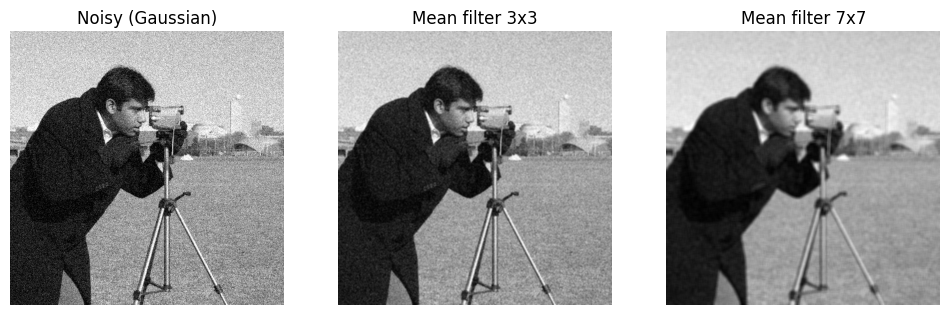

MSE noisy: 0.009061243385076523
MSE mean3: 0.002221661387011409
MSE mean7: 0.0033750133588910103


In [36]:
mean3 = uniform_filter(g, size=3) # the same as the mean filter
mean7 = uniform_filter(g, size=7) 
 
plt.figure(figsize=(12,4)) 
plt.subplot(1,3,1) 
plt.imshow(g, cmap="gray") 
plt.title("Noisy (Gaussian)") 
plt.axis("off") 
 
plt.subplot(1,3,2) 
plt.imshow(mean3, cmap="gray") 
plt.title("Mean filter 3x3") 
plt.axis("off") 
 
plt.subplot(1,3,3) 
plt.imshow(mean7, cmap="gray") 
plt.title("Mean filter 7x7") 
plt.axis("off") 
plt.show() 
 
print("MSE noisy:", mse(img, g)) 
print("MSE mean3:", mse(img, mean3)) 
print("MSE mean7:", mse(img, mean7)) 

# Questions 
# 1. Which window size gives lower MSE?  
# window of 3
# 2. Which window size causes more edge blur, and why? 
# window 7, it is bigger and takes the mean of 
# 49 pixel all together making it blur

### 5. Geometric mean filtering 
Exercise 5.1: Implement a geometric mean filter (code) 

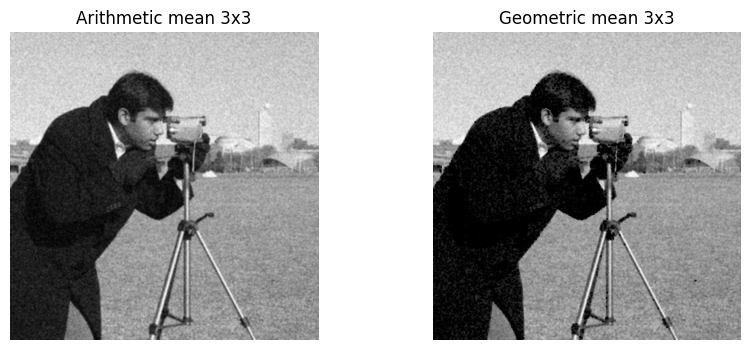

MSE mean3: 0.002221661387011409
MSE geo3: 0.003962727263569832


In [37]:
def geometric_mean_filter(im, size=3, eps=1e-6): 
    # log-domain to avoid underflow 
    im2 = np.clip(im, eps, 1.0) 
    log_im = np.log(im2) 
    m = uniform_filter(log_im, size=size) 
    return np.exp(m) # because of the sigma of ln times the 1/mn so this makes it mean of the ln of pixels in the filter, so we take the exp so ln can go, remember the range in the image is 0,1
 
geo3 = geometric_mean_filter(g, size=3) 
 
plt.figure(figsize=(10,4)) 
plt.subplot(1,2,1) 
plt.imshow(mean3, cmap="gray") 
plt.title("Arithmetic mean 3x3") 
plt.axis("off") 
 
plt.subplot(1,2,2) 
plt.imshow(geo3, cmap="gray") 
plt.title("Geometric mean 3x3") 
plt.axis("off") 
plt.show() 

# Tasks 
# 1. Show what happens if eps is set to 0 and explain the failure. 
# the result is a little bit scary, it is like someone bites the image, it is because the log(0) are -inf
# and python will no longer handle inf calculations so the rest of the image is not calculated
# 2. Compare geometric mean with arithmetic mean using MSE and edge appearance. 
print("MSE mean3:", mse(img, mean3))
print("MSE geo3:", mse(img, geo3)) 

### 6. Contraharmonic mean filter 
Exercise 6.1: Implement contraharmonic filter and test salt vs pepper 
removal (code) 


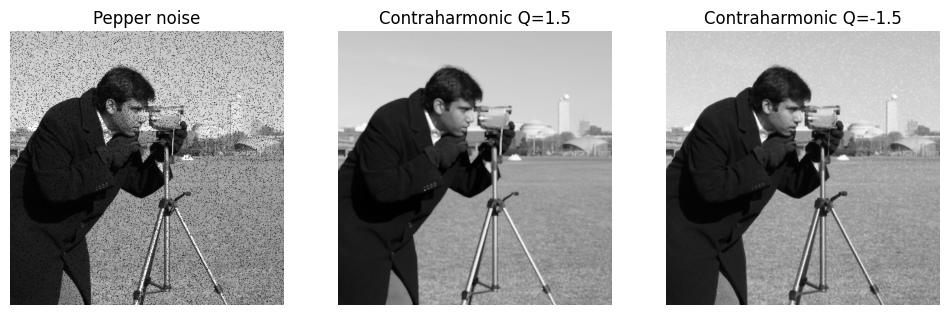

MSE of image and fixed pepper noise: 0.002
MSE for image and fixed salt noise: 0.002


In [ ]:
from scipy.ndimage import generic_filter 
 
def contraharmonic(im, size=3, Q=1.5, eps=1e-6): 
    def f(window): 
        w = np.array(window, dtype=np.float32) 
        num = np.sum((w + eps) ** (Q + 1)) 
        den = np.sum((w + eps) ** Q) 
        return num / (den + eps) 
    return generic_filter(im, f, size=size) 
 
# Create separate salt-heavy and pepper-heavy examples 
sp_more_salt = util.random_noise(img, mode="salt", 
amount=0.08).astype(np.float32) 
sp_more_pepper = util.random_noise(img, mode="pepper", 
amount=0.08).astype(np.float32) 
 
Q_pos = 1.5   # should reduce pepper 
Q_neg = -1.5  # should reduce salt 
 
pepper_fixed = contraharmonic(sp_more_pepper, size=3, Q=Q_pos) 
salt_fixed = contraharmonic(sp_more_salt, size=3, Q=Q_neg) 
 
plt.figure(figsize=(12,4)) 
plt.subplot(1,3,1) 
plt.imshow(sp_more_pepper, cmap="gray") 
plt.title("Pepper noise") 
plt.axis("off") 
 
plt.subplot(1,3,2) 
plt.imshow(pepper_fixed, cmap="gray") 
plt.title(f"Contraharmonic Q={Q_pos}") 
plt.axis("off") 

# u can print the salt noisy image 

plt.subplot(1,3,3) 
plt.imshow(salt_fixed, cmap="gray") 
plt.title(f"Contraharmonic Q={Q_neg}") 
plt.axis("off") 
plt.show() 

# print the mse and compare
print(f"MSE of image and fixed pepper noise: {mse(img, pepper_fixed):.3f}\nMSE for image and fixed salt noise: {mse(img, salt_fixed):.3f}")

# Questions 
# 1. Why does positive Q suppress pepper noise? 
# because according to the filter formula, rising to a positive power will result in darker values becoming dominant, and lighter colors become even smaller
# 2. Why does negative Q suppress salt noise? 
# because according to the filter formula, rising to a negative power will result in lighter values becoming dominant, and darker colors become even smaller
# 3. What visual artefact appears if Q is chosen incorrectly?
# either noise will have stronger effects on the image, with large Q the image will become darker, and the opposite for smaller Q producing lighter image

### 7. Median filter for impulse noise 
Exercise 7.1: Median filter and repeated application (code) 

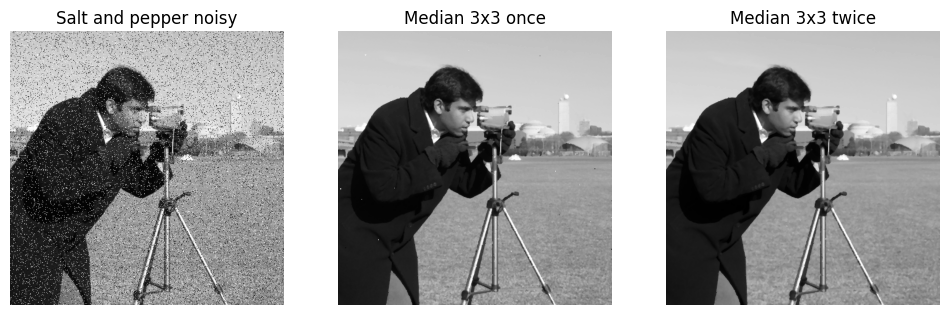

MSE noisy: 0.03353644907474518
MSE med once: 0.0011326175881549716
MSE med twice: 0.0010959743522107601


In [ ]:
med3 = median_filter(sp, size=3) 
med3_twice = median_filter(med3, size=3) 
 
plt.figure(figsize=(12,4)) 
plt.subplot(1,3,1) 
plt.imshow(sp, cmap="gray") 
plt.title("Salt and pepper noisy") 
plt.axis("off") 
 
plt.subplot(1,3,2) 
plt.imshow(med3, cmap="gray")  
plt.title("Median 3x3 once") 
plt.axis("off") 
 
plt.subplot(1,3,3) 
plt.imshow(med3_twice, cmap="gray") 
plt.title("Median 3x3 twice") 
plt.axis("off") 
plt.show() 
 
print("MSE noisy:", mse(img, sp)) 
print("MSE med once:", mse(img, med3)) 
print("MSE med twice:", mse(img, med3_twice)) 

# Tasks 
# 1. Explain why median filtering works well for salt and pepper noise.
# it avoids choosing the extreme values at min and max
# 2. Explain why repeated median filtering can distort fine details. 
# because fine details can have extreme values (for example edges), but they are not as extreme as s&p noise
# so applying the median filter nultiple times will lead to picking the intensity values of broad objects distorting tiny details

### 8. Min, max, and midpoint filters 
Exercise 8.1: Implement min, max, and midpoint filtering (code) 

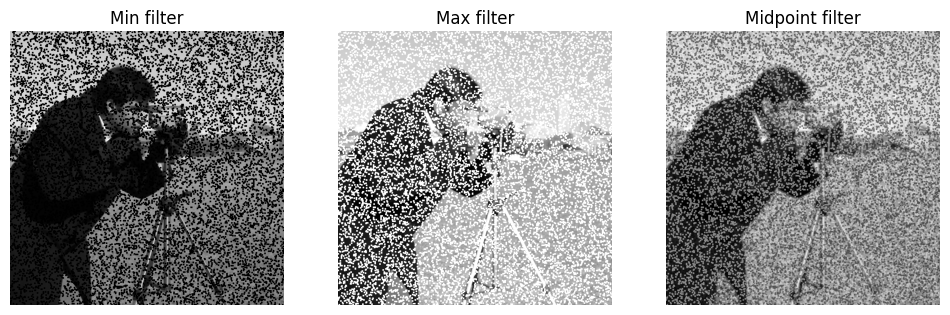

In [ ]:
from scipy.ndimage import minimum_filter, maximum_filter 
 
minf = minimum_filter(sp, size=3) 
maxf = maximum_filter(sp, size=3) 
mid = 0.5 * (minf + maxf) 
 
plt.figure(figsize=(12,4)) 
plt.subplot(1,3,1) 
plt.imshow(minf, cmap="gray") 
plt.title("Min filter") 
plt.axis("off") 
 
plt.subplot(1,3,2) 
plt.imshow(maxf, cmap="gray") 
plt.title("Max filter") 
plt.axis("off") 
 
plt.subplot(1,3,3) 
plt.imshow(mid, cmap="gray") 
plt.title("Midpoint filter") 
plt.axis("off") 
plt.show() 

# Questions 
# 1. Which filter suppresses salt noise more, and why? 
# max filter, it picks the highest values between applied pixels which are mostly salt noise, and this increase the noise
# 2. Which filter suppresses pepper noise more, and why? 
# min filter, it picks the lowest values between applied pixels which are mostly pepper noise, and this increase the noise
# 3. Why does midpoint filtering fail for impulse noise? 
# because choosing the mid point between many pixels with extreme values (S&P) will result in middle gray levels, as shown bellow in the last filter

### 9. Alpha trimmed mean filter 
Exercise 9.1: Implement alpha trimmed mean filtering (code) 

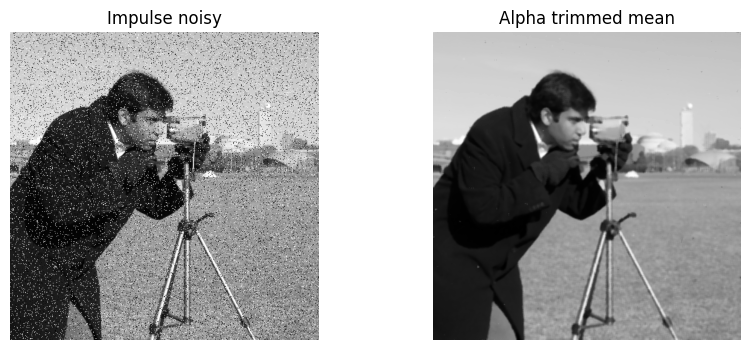

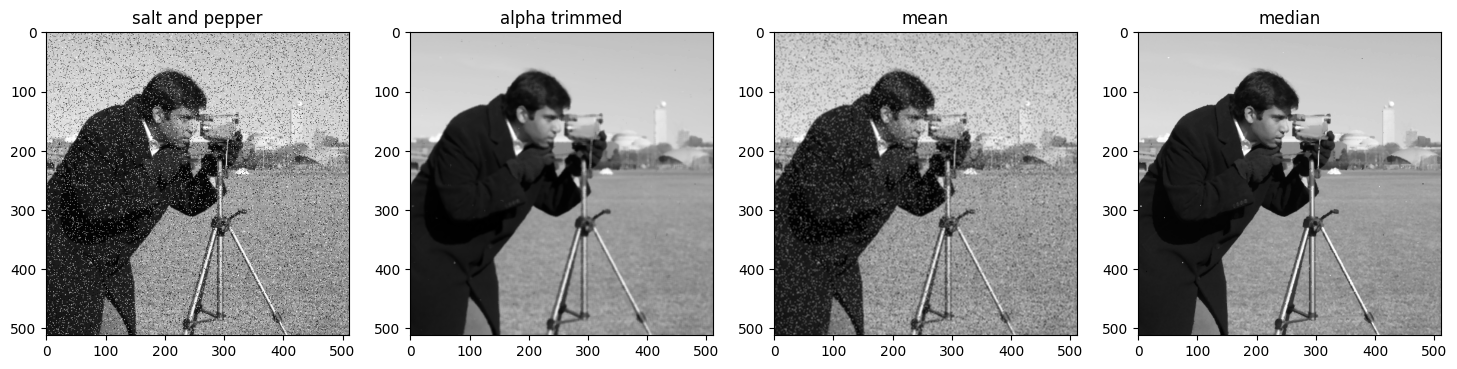

In [ ]:
from scipy.ndimage import generic_filter 
 
def alpha_trimmed_mean(im, size=5, d=10): 
    # size x size window has n=size*size values, remove d/2 lowest and d/2 highest 
    n = size * size 
    d = int(np.clip(d, 0, n-1)) 
    trim = d // 2 
 
    def f(window): 
        w = np.sort(np.array(window, dtype=np.float32)) 
        if trim > 0: 
            w = w[trim:-trim] 
        return float(np.mean(w)) 
 
    return generic_filter(im, f, size=size) 
 
atm = alpha_trimmed_mean(sp, size=5, d=10) 
 
plt.figure(figsize=(10,4)) 
plt.subplot(1,2,1) 
plt.imshow(sp, cmap="gray") 
plt.title("Impulse noisy") 
plt.axis("off") 
 
plt.subplot(1,2,2) 
plt.imshow(atm, cmap="gray") 
plt.title("Alpha trimmed mean") 
plt.axis("off") 
plt.show() 

# Tasks 
# 1. Change d and explain what happens when trimming is too small or too large. 
# if its too small, the noise will not be erased completely
# 2. Compare alpha trimmed mean with mean and median on impulse noise. 
mean_sp = uniform_filter(sp, size=3)
median_sp = median_filter(sp, size=3)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(sp, cmap='gray'); axes[0].set_title("salt and pepper")
axes[1].imshow(atm, cmap='gray'); axes[1].set_title("alpha trimmed")
axes[2].imshow(mean_sp, cmap='gray'); axes[2].set_title("mean")
axes[3].imshow(median_sp, cmap='gray'); axes[3].set_title("median")
plt.show()
# median and alpha trimmed produce super similar results due toi their similar math behavior